In [85]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from overview import FigureType, StatisticLine, feature_overview

df = pd.read_csv('data/train.csv', index_col='id')
# load original dataset
original = pd.read_csv('data/rainfall.csv').drop(59).reset_index(drop=True)
original.columns = original.columns.str.strip()
original.day = original.index.values + 1
original.rainfall = original.rainfall.apply(lambda value: int(value == 'yes'))
fill_values = original[df.columns].mean()
df = pd.concat([df[df.columns], original[df.columns].fillna(fill_values)])

__Basic overview__

In [87]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [88]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000,2555.000000
mean,180.384344,1013.618043,26.341409,23.925714,22.133659,20.391937,81.778474,75.086106,3.838395,104.407818,21.768278,0.743249
std,105.232242,5.766286,5.702010,5.282416,5.137625,5.394003,8.177998,18.648849,3.677042,80.232879,9.921260,0.436927
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000,0.000000
25%,89.000000,1008.600000,21.300000,19.300000,17.650000,16.800000,77.000000,68.000000,0.400000,40.000000,14.100000,0.000000
50%,179.000000,1013.000000,27.800000,25.500000,23.800000,22.100000,81.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,270.500000,1017.800000,31.200000,28.400000,26.500000,25.000000,87.000000,88.000000,7.000000,200.000000,27.900000,1.000000
max,365.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000,1.000000


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2555 entries, 0 to 364
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2555 non-null   int64  
 1   pressure       2555 non-null   float64
 2   maxtemp        2555 non-null   float64
 3   temparature    2555 non-null   float64
 4   mintemp        2555 non-null   float64
 5   dewpoint       2555 non-null   float64
 6   humidity       2555 non-null   float64
 7   cloud          2555 non-null   float64
 8   sunshine       2555 non-null   float64
 9   winddirection  2555 non-null   float64
 10  windspeed      2555 non-null   float64
 11  rainfall       2555 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 259.5 KB


In [90]:
# classes balance
df.rainfall.value_counts()

rainfall
1    1899
0     656
Name: count, dtype: int64

__Features overview__

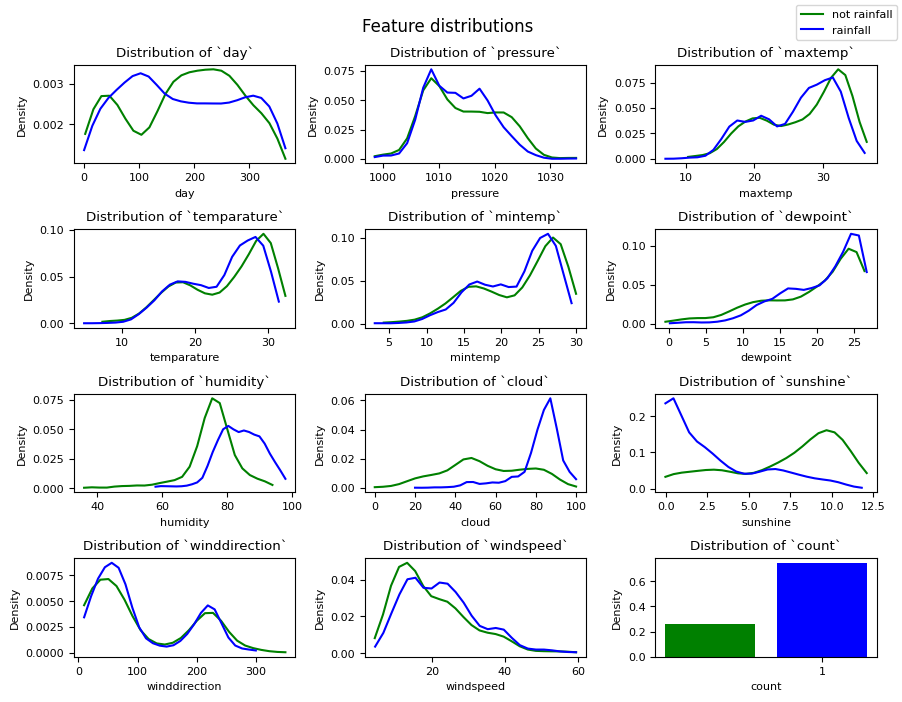

In [91]:
COLUMNS = 3
ROWS = np.ceil(len(df.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(df.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'rainfall':
        feature_overview(ax[row][col], df.loc[df.rainfall == 0, feature].value_counts() / df.shape[0], FigureType.BAR, color='green')
        feature_overview(ax[row][col], df.loc[df.rainfall == 1, feature].value_counts() / df.shape[0], FigureType.BAR, color='blue')
        continue
    feature_overview(ax[row][col], df.loc[df.rainfall == 0, feature], FigureType.DENSITY, bins=25, color='green')
    feature_overview(ax[row][col], df.loc[df.rainfall == 1, feature], FigureType.DENSITY, bins=25, color='blue')

fig.legend(['not rainfall', 'rainfall'])
plt.show()

__Correlations__

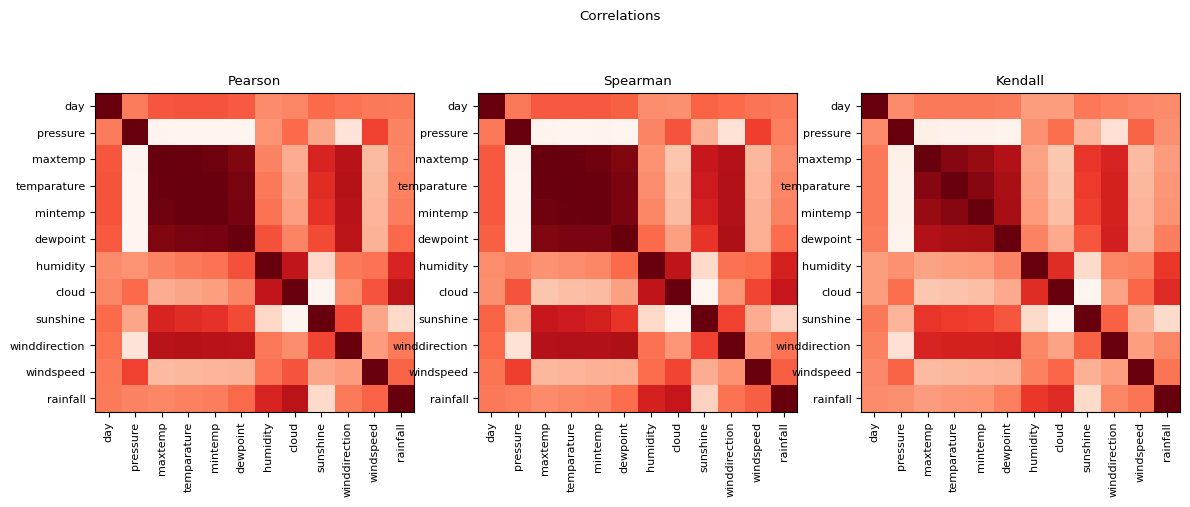

In [92]:
data = df.copy()
rainfall = data.rainfall
CORRELATIONS = ('pearson', 'spearman', 'kendall')
# drawing
fig, axes = plt.subplots(1, len(CORRELATIONS), figsize=(14, 5))
# fig.set_layout_engine('none')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    # ax[n].tick_params(axis='x', rotation=90)
    ax.imshow(data.corr(method), cmap='Reds')
    ax.set_xticks(range(len(data.columns)), labels=data.columns, rotation=90)
    ax.set_yticks(range(len(data.columns)), labels=data.columns)
plt.show()

In [ ]:
#